# Statistiques de voc

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lrivals/EmbeddedComputervision/blob/main/notebooks/voc/voc_stats.ipynb)

Présentation et analyse statistique du jeu, lues du point de vue de Tiny-YOLO et de la
cible embarquée (entrée 416, grilles 13×13 et 26×26, 256 emplacements de `yolo_post`,
INT8). Tâches : [T13.7](../../docs/tasks/M13-figures.md), [T16.12](../../docs/tasks/M16-presentation-jeux.md), [T16.4](../../docs/tasks/M16-presentation-jeux.md) ; jalon : [M16](../../docs/tasks/M16-presentation-jeux.md) ;
synthèse : [stats-jeux.md](../../docs/tasks/stats-jeux.md). Autres notebooks du jeu :
[tiny-yolov2-voc_infer](tiny-yolov2-voc_infer.ipynb), [tiny-yolov3-coco_infer](tiny-yolov3-coco_infer.ipynb), [tiny-yolov3-voc_infer](tiny-yolov3-voc_infer.ipynb), [tiny-yolov3-voc_train](tiny-yolov3-voc_train.ipynb), [tiny-yolov3-voc_sweep](tiny-yolov3-voc_sweep.ipynb).

Palier : annotations **R** (split entier), pixels **M** (`SAMPLE = 200`
images par partie). Prérequis : données `data/VOCdevkit/VOC2007/ImageSets/Main/test.txt` — tools/get_voc.sh. Ni poids ni GPU.

Question propre : Les classes à faible AP (bottle, pottedplant) sont-elles rares ou petites ? (renvoi : T13.7, T13.13).

| | |
|---|---|
| source | http://host.robots.ox.ac.uk/pascal/VOC/ |
| version | VOC2007 (test, trainval), VOC2012 (trainval) |
| licence | images Flickr (conditions de Flickr), annotations pour la recherche |
| capteur | photos grand public de Flickr, scènes de la vie courante, couleur |
| résolution typique | ≈ 500×375 |
| officiel `2007:test` | 4952 images, 12032 objets |
| officiel `2007:trainval` | 5011 images, 12608 objets |
| officiel `2012:trainval` | 11540 images, 27450 objets |
| chargeur | objets `difficult` gardés, ignorés par l'évaluation VOC |
| chargeur | test : 2007:test ; calibration : 2007:trainval ; affinage : 07+12 trainval |

Aucun calcul ici : `tools/data_stats.py` calcule (`stats.json`, `stats.md`, galerie),
`tools/figures/donnees.py` trace ; chaque étape affiche la commande. Sorties dans
`build/notebooks/voc/stats/`, jamais dans `results/`. Notebook généré par `python -m tools.notebooks`
(`make notebooks`) : modifier `tools/notebooks/gabarits.py`, pas ce fichier.

## Paramètres

In [1]:
DATASET   = 'voc'  # clé de DATASETS
SPLITS    = None  # liste de splits ; None : splits train puis test du jeu
SIZE      = None  # S ou 'LxH' ; None : entrée de la cfg du jeu (416 sinon)
RESIZE    = 'letterbox'  # letterbox | stretch (grandeurs vues par le réseau)
SAMPLE    = 200  # images lues pour les pixels, par partie ; 0 : aucune
GALLERY   = 8  # images de la galerie par split
SEED      = 0  # tirage des images (pixels, galerie, nuages)
NET       = 'tiny-yolov3-voc'  # cfg dont les ancres et grilles servent aux collisions
DEVICE    = 'cpu'  # noyau CPU : rien ne tourne sur GPU
DATA_ROOT = None  # racine du jeu ; None : data/<jeu> (Colab : dossier Drive)
DRIVE_DIR = '/content/drive/MyDrive/EmbeddedCV'  # Colab : archives data/<jeu>.tar ; None : pas de Drive
OUT       = 'build/notebooks/voc/stats'  # sorties du notebook
REPO_URL  = 'https://github.com/lrivals/EmbeddedComputervision.git'  # Colab : dépôt cloné
REV       = 'main'  # Colab : révision

## Environnement

Local : rien n'est installé ni téléchargé, la cellule vérifie les prérequis et
s'arrête avec la commande à lancer. Colab : clone du dépôt, installation, CuPy si
`DEVICE = "gpu"`, poids, puis données par `colab.prepare_data` (archive
`<DRIVE_DIR>/data/<jeu>.tar` ou téléchargement direct ; ExDark et FLIR : archive
seulement, faite sur le PC par `tools/get_datasets.sh pack <jeu>`).

In [2]:
import os
import subprocess
import sys
from pathlib import Path

COLAB = "google.colab" in sys.modules


def repo_root():
    for d in (Path.cwd(), *Path.cwd().parents):
        if (d / "tools" / "notebooks" / "commandes.py").exists():
            return d
    return None


ROOT = repo_root()
if COLAB:
    if ROOT is None:
        ROOT = Path("/content/EmbeddedComputervision")
        if not ROOT.exists():
            subprocess.run(["git", "clone", REPO_URL, str(ROOT)], check=True)
    # Clone d'une session précédente : remis à REV (notebook et code du même commit).
    subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin", REV], check=True)
    subprocess.run(["git", "-C", str(ROOT), "checkout", "-q", "FETCH_HEAD"], check=True)
    for m in [m for m in sys.modules if m.split(".")[0] in ("tools", "yolo")]:
        del sys.modules[m]  # modules importés avant la mise à jour
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    f"{ROOT}/python[data,plots]"], check=True)
    if DEVICE == "gpu":
        # Runtime CPU : pas de pilote, CuPy dirait « cudaErrorInsufficientDriver ».
        try:
            smi = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
        except FileNotFoundError:
            smi = None
        if smi is None or smi.returncode != 0:
            raise RuntimeError("runtime Colab sans GPU : créer un nouveau serveur Colab "
                               "de type GPU (T4, L4 ou A100), ou DEVICE = 'cpu'")
        cuda = smi.stdout.split("CUDA Version:")[-1].split()[0]  # version du pilote
        cupy_pkg = "cupy-cuda13x" if int(cuda.split(".")[0]) >= 13 else "cupy-cuda12x"
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", cupy_pkg],
                       check=True)
elif ROOT is None:
    raise RuntimeError("racine du dépôt introuvable : ouvrir le notebook depuis notebooks/")
os.chdir(ROOT)
for p in (ROOT, ROOT / "python"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from tools.notebooks import commandes as C
from tools.notebooks import env

TRACE = env.trace(DEVICE)
env.check_device(DEVICE)
env.prepare(DATASET, (), None, DATA_ROOT, COLAB, hint='',
            drive_dir=DRIVE_DIR)
if str(NET).endswith(".cfg") and not env.restore_cfg(NET):
    print(f"cfg {NET} absente (tools/m11.sh {DATASET}-prep) : ancres et grilles de "
          "tiny-yolov3-coco pour les collisions")
    NET = "tiny-yolov3-coco"
Path(OUT).mkdir(parents=True, exist_ok=True)

dépôt /home/leonard/Documents/Perso/EmbeddedComputervision @ 214f269 (modifié) ; Python 3.12.3 ; NumPy 2.4.2 ; backend cpu
données voc : data/VOCdevkit/VOC2007/ImageSets/Main/test.txt ; poids : —


## Calcul (T16.0)

`tools/data_stats.py` lit les annotations de chaque split (en entier), lit les pixels
de `SAMPLE` images par partie (tirées avec `SEED`), dessine la galerie et trace les
figures. Les grandeurs « vues par le réseau » sont calculées après `RESIZE` à `SIZE`.

In [3]:
import json

from IPython.display import Image as Img, Markdown, display

from tools import data_stats as DS
from tools.notebooks.matrice import SPLIT_IMAGES, palier_stats
from yolo.models.tiny_yolo import load_cfg

if SIZE is None:
    _, h, w = load_cfg(NET)["input"]
    SIZE = h if h == w else f"{w}x{h}"
ann, px = palier_stats(DATASET, SAMPLE)
print(f"palier : annotations {ann}, pixels {px} ({SAMPLE} images par partie) ; "
      f"entrée {SIZE} ({RESIZE}) ; cfg {NET}")
C.run(C.cmd_data_stats(DATASET, OUT, SPLITS, SIZE, RESIZE, NET, SAMPLE, GALLERY, SEED,
                       data_root=DATA_ROOT))
STATS = json.loads(Path(OUT, "stats.json").read_text())
FIG = Path(OUT, "figures")


def show(name):
    png = FIG / f"{name}.png"
    if png.exists():
        display(Img(filename=str(png)))


def table(fn):
    text = fn(STATS)
    if text:
        display(Markdown(text))

palier : annotations R, pixels M (200 images par partie) ; entrée 416 (letterbox) ; cfg tiny-yolov3-voc
$ python tools/data_stats.py --dataset voc --size 416 --resize letterbox --net tiny-yolov3-voc --sample 200 --gallery 8 --seed 0 --figures --out build/notebooks/voc/stats


chargement voc 2007:trainval…


chargement voc 2012:trainval…


chargement voc 2007:test…


analyses 2007:trainval (5011 images)…


...

→ build/notebooks/voc/stats/figures/intensites.png


→ build/notebooks/voc/stats/figures/ancres.png


→ build/notebooks/voc/stats/figures/ancres_k.png


→ build/notebooks/voc/stats/figures/ecart.png


  (26 s)


## Présentation et galerie (T16.4)

Classes du jeu et leur correspondance VOC et COCO (`MAPPINGS`), puis `GALLERY` images
par split, une image par classe ; vérités terrain dessinées par `tools/detect.py:draw`.
À `SEED` fixé, la galerie ne change pas.

| classe | VOC | COCO |
|---|---|---|
| aeroplane | aeroplane | aeroplane |
| bicycle | bicycle | bicycle |
| bird | bird | bird |
| boat | boat | boat |
| bottle | bottle | bottle |
| bus | bus | bus |
| car | car | car |
| cat | cat | cat |
| chair | chair | chair |
| cow | cow | cow |
| diningtable | diningtable | diningtable |
| dog | dog | dog |
| horse | horse | horse |
| motorbike | motorbike | motorbike |
| person | person | person |
| pottedplant | pottedplant | pottedplant |
| sheep | sheep | sheep |
| sofa | sofa | sofa |
| train | train | train |
| tvmonitor | tvmonitor | tvmonitor |

galerie : 2007:trainval


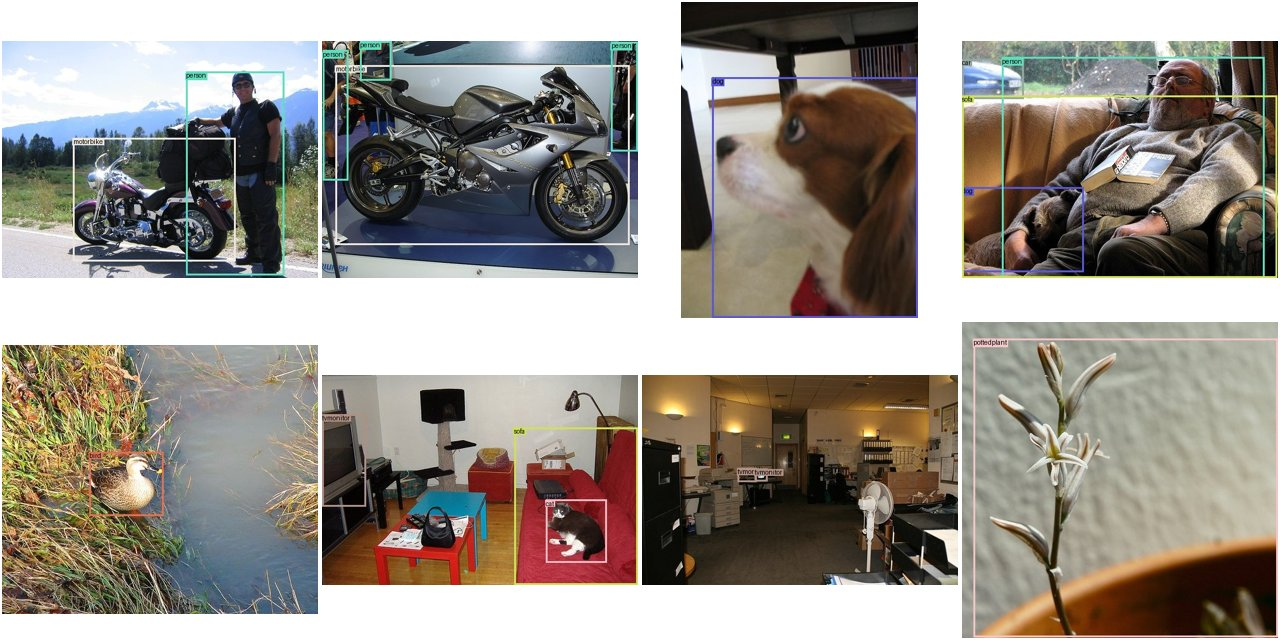

galerie : 2012:trainval


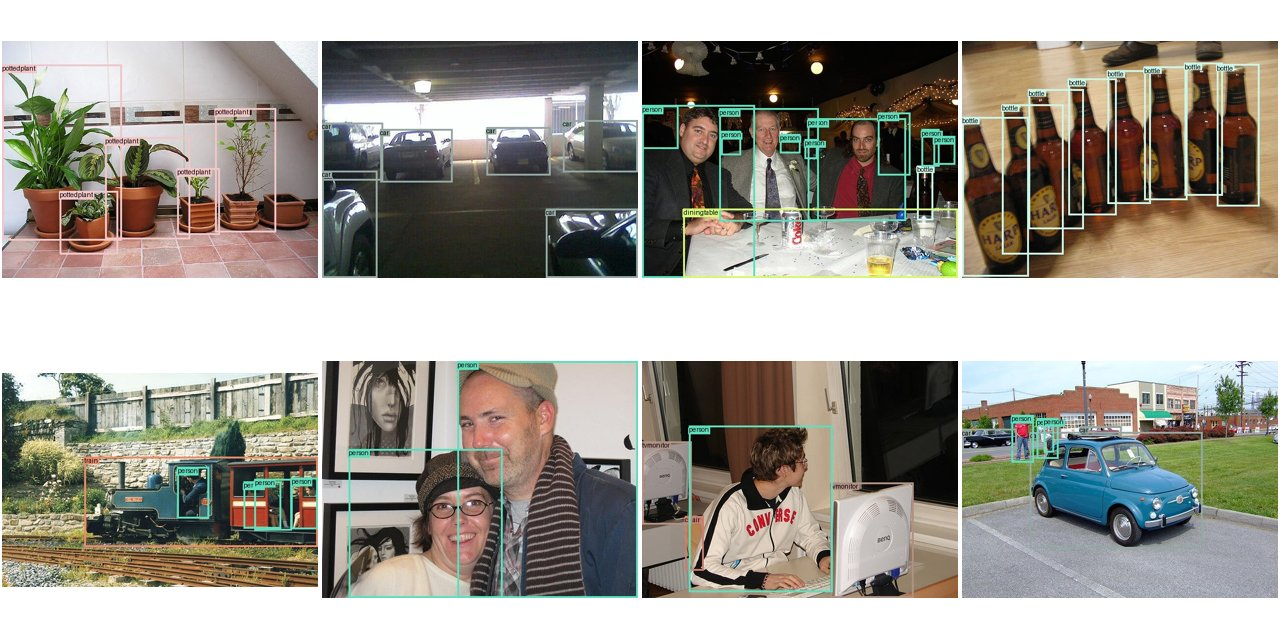

galerie : 2007:test


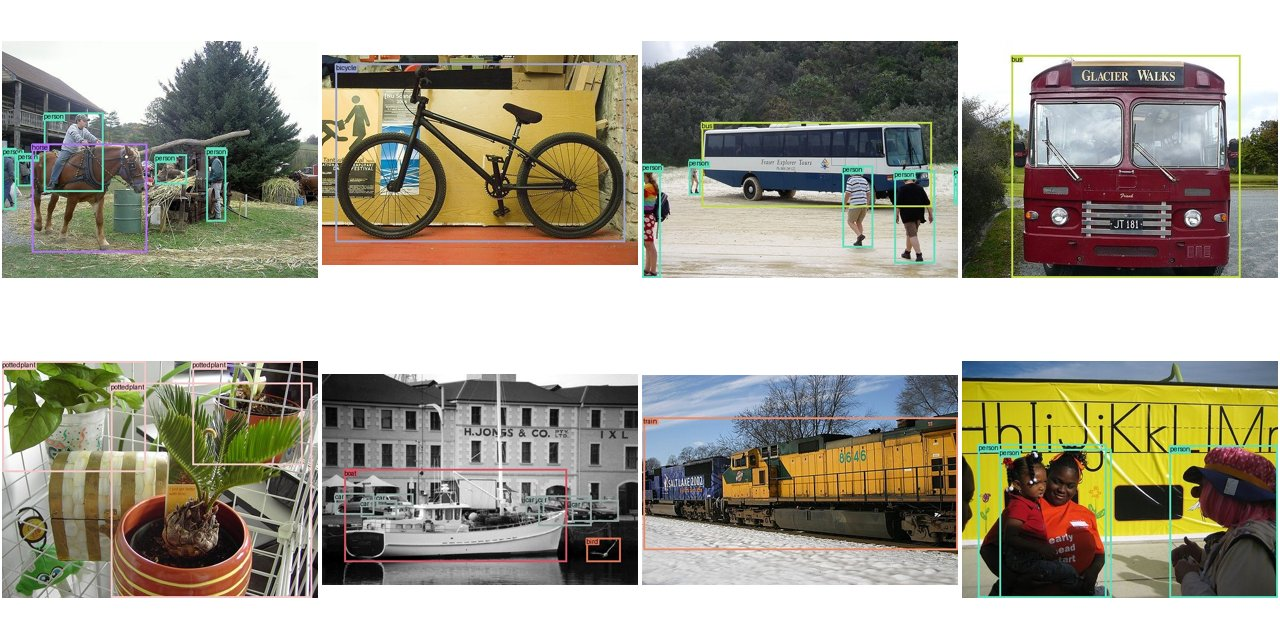

galerie : classes


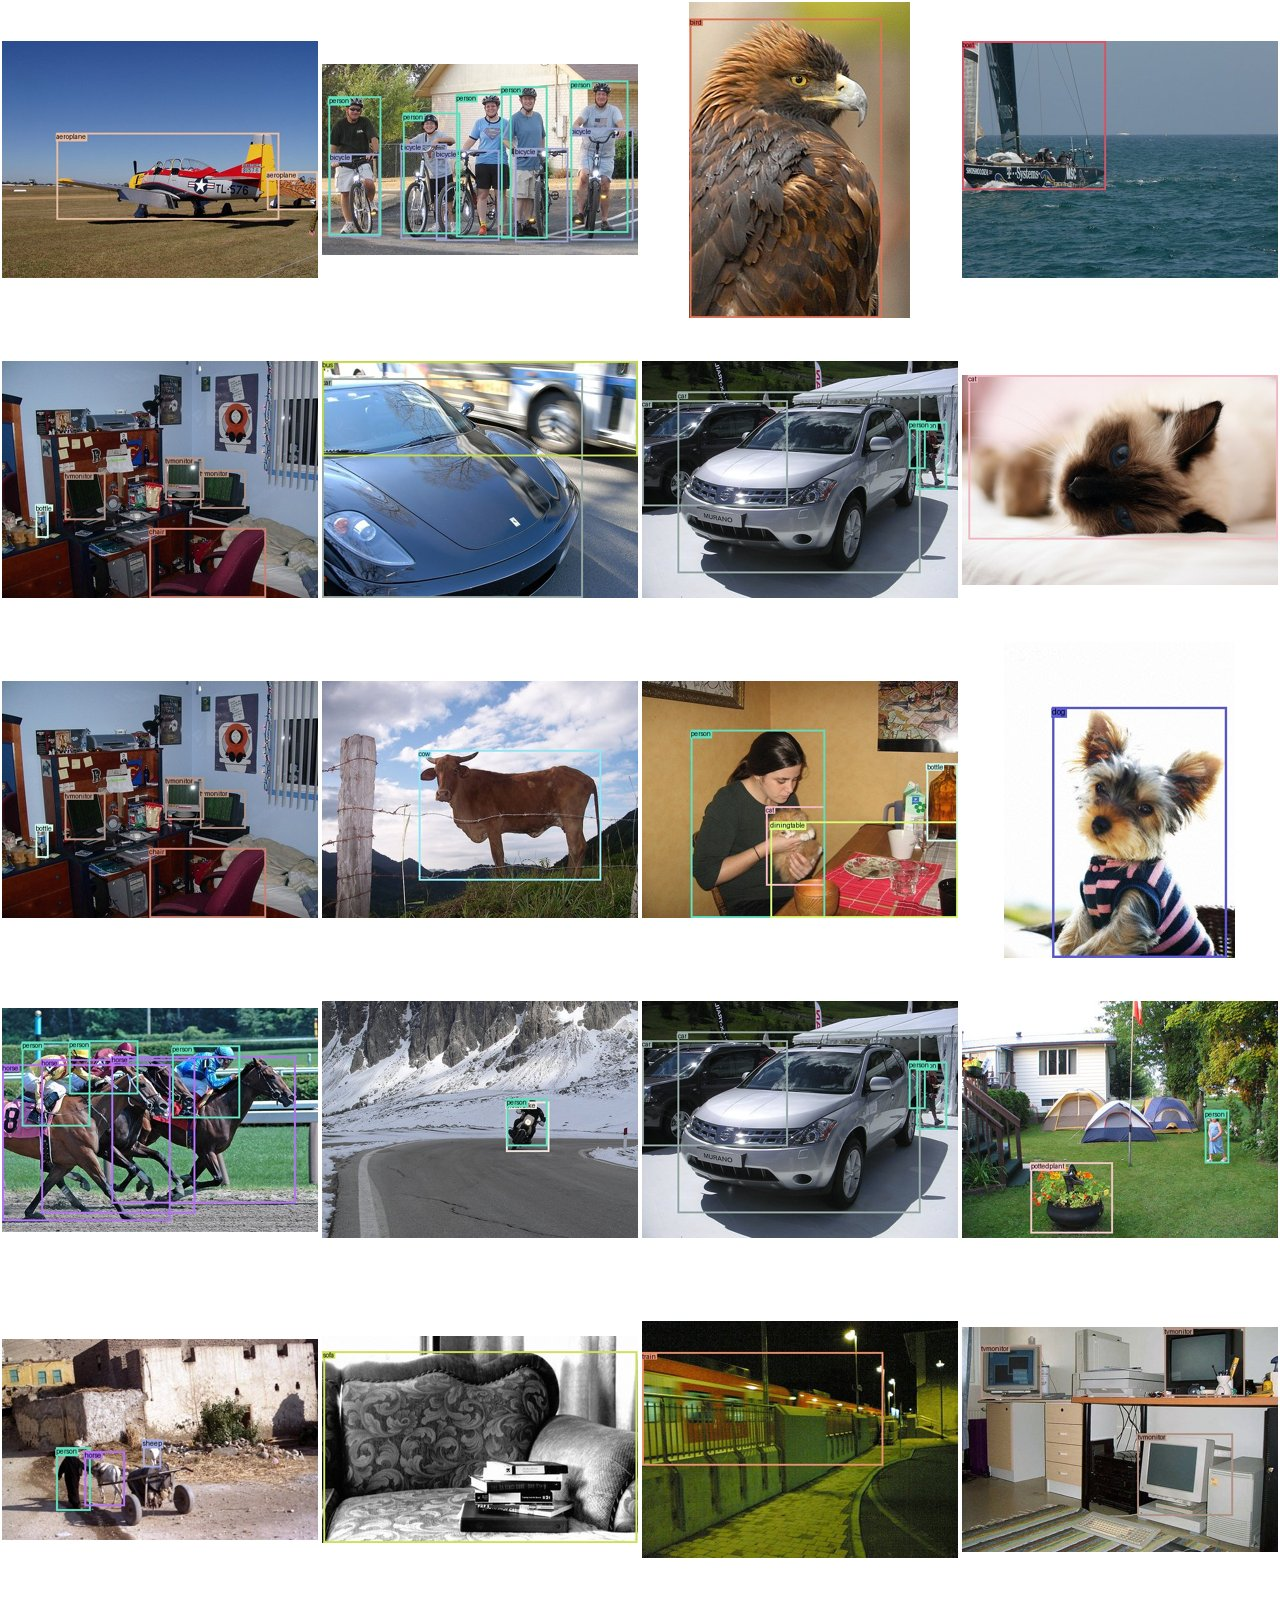

In [4]:
from yolo.data import datasets as D

rows = ["| classe | VOC | COCO |", "|---|---|---|"]
for c in D.DATASETS[DATASET].classes:
    m = [c if DATASET == f else D.MAPPINGS.get((DATASET, f), {}).get(c, "—")
         for f in ("voc", "coco")]
    rows.append(f"| {c} | {m[0]} | {m[1]} |")
display(Markdown("\n".join(rows)))
for g, sheet in STATS.get("galerie", {}).get("planches", {}).items():
    if g != "suspectes":
        print(f"galerie : {g}")
        display(Img(filename=str(Path(OUT, sheet))))

## Comptes et classes (T16.5)

Comptes par split (annotations, split entier), face aux effectifs officiels de la
fiche ; objets par classe et co-occurrence.

| partie | images | objets | difficult | images vides | objets/image (méd. / max) | petits < 32² à 416×416 | plus petits qu'une cellule | cibles perdues | images > 256 / > 1 024 |
|---|---|---|---|---|---|---|---|---|---|
| 2007:trainval | 5 011 | 15 662 | 3 054 | 0 | 2 / 42 | 7,7 % | 13x13 3,2 % · 26x26 0,1 % | 0,62 % | 0 / 0 |
| 2012:trainval | 11 540 | 31 561 | 4 111 | 0 | 2 / 56 | 9,1 % | 13x13 4,7 % · 26x26 0,4 % | 0,73 % | 0 / 0 |
| 2007:test | 4 952 | 14 976 | 2 944 | 0 | 2 / 41 | 7,3 % | 13x13 3,5 % · 26x26 0,1 % | 0,66 % | 0 / 0 |
| groupe train | 16 551 | 47 223 | 7 165 | 0 | 2 / 56 | 8,7 % | 13x13 4,2 % · 26x26 0,3 % | 0,69 % | 0 / 0 |
| ensemble | 21 503 | 62 199 | 10 109 | 0 | 2 / 56 | 8,4 % | 13x13 4,0 % · 26x26 0,3 % | 0,69 % | 0 / 0 |

2007:test : 4952 images, 12032 objets ; officiel 4952 / 12032 : ok
2007:trainval : 5011 images, 12608 objets ; officiel 5011 / 12608 : ok
2012:trainval : 11540 images, 27450 objets ; officiel 11540 / 27450 : ok


| classe | 2007:trainval : objets (images) | 2012:trainval : objets (images) | 2007:test : objets (images) | côté médian (px, letterbox) | petits |
|---|---|---|---|---|---|
| aeroplane | 331 (240) | 954 (676) | 311 (205) | 170 | 9 % |
| bicycle | 418 (255) | 790 (571) | 389 (250) | 136 | 3 % |
| bird | 599 (333) | 1 221 (773) | 576 (289) | 112 | 8 % |
| boat | 398 (188) | 999 (516) | 393 (176) | 90 | 13 % |
| bottle | 634 (262) | 1 482 (768) | 657 (240) | 51 | 24 % |
| bus | 272 (197) | 637 (430) | 254 (183) | 171 | 3 % |
| car | 1 644 (761) | 2 364 (1 229) | 1 541 (775) | 79 | 16 % |
| cat | 389 (344) | 1 227 (1 084) | 370 (332) | 234 | 0 % |
| chair | 1 432 (572) | 2 906 (1 298) | 1 374 (545) | 93 | 4 % |
| cow | 356 (146) | 702 (309) | 329 (127) | 108 | 8 % |
| diningtable | 310 (263) | 747 (641) | 299 (247) | 182 | 1 % |
| dog | 538 (430) | 1 541 (1 297) | 530 (433) | 193 | 1 % |
| horse | 406 (294) | 750 (483) | 395 (279) | 175 | 2 % |
| motorbike | 390 (249) | 751 (536) | 369 (233) | 165 | 2 % |
| person | 5 447 (2 095) | 10 129 (4 374) | 5 227 (2 097) | 111 | 10 % |
| pottedplant | 625 (273) | 1 099 (568) | 592 (254) | 71 | 15 % |
| sheep | 353 (97) | 994 (326) | 311 (98) | 79 | 15 % |
| sofa | 425 (372) | 786 (695) | 396 (355) | 194 | 0 % |
| train | 328 (263) | 656 (550) | 302 (259) | 199 | 1 % |
| tvmonitor | 367 (279) | 826 (595) | 361 (255) | 90 | 4 % |

Rapport classe la plus / la moins fréquente : 18.

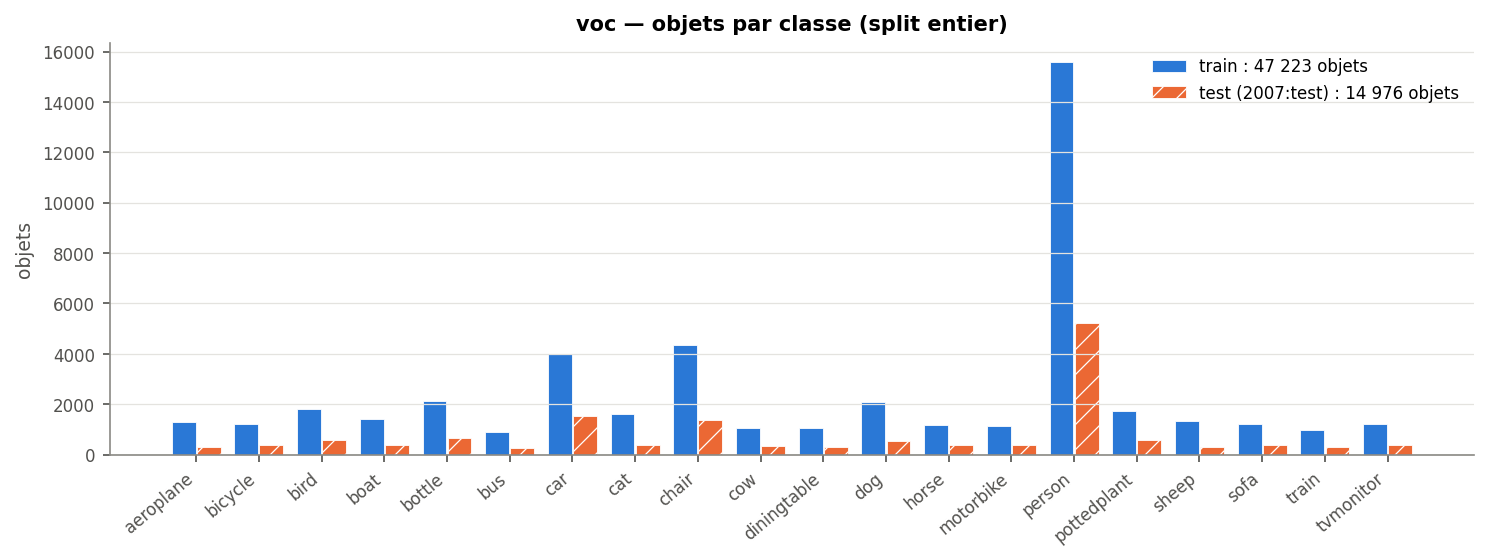

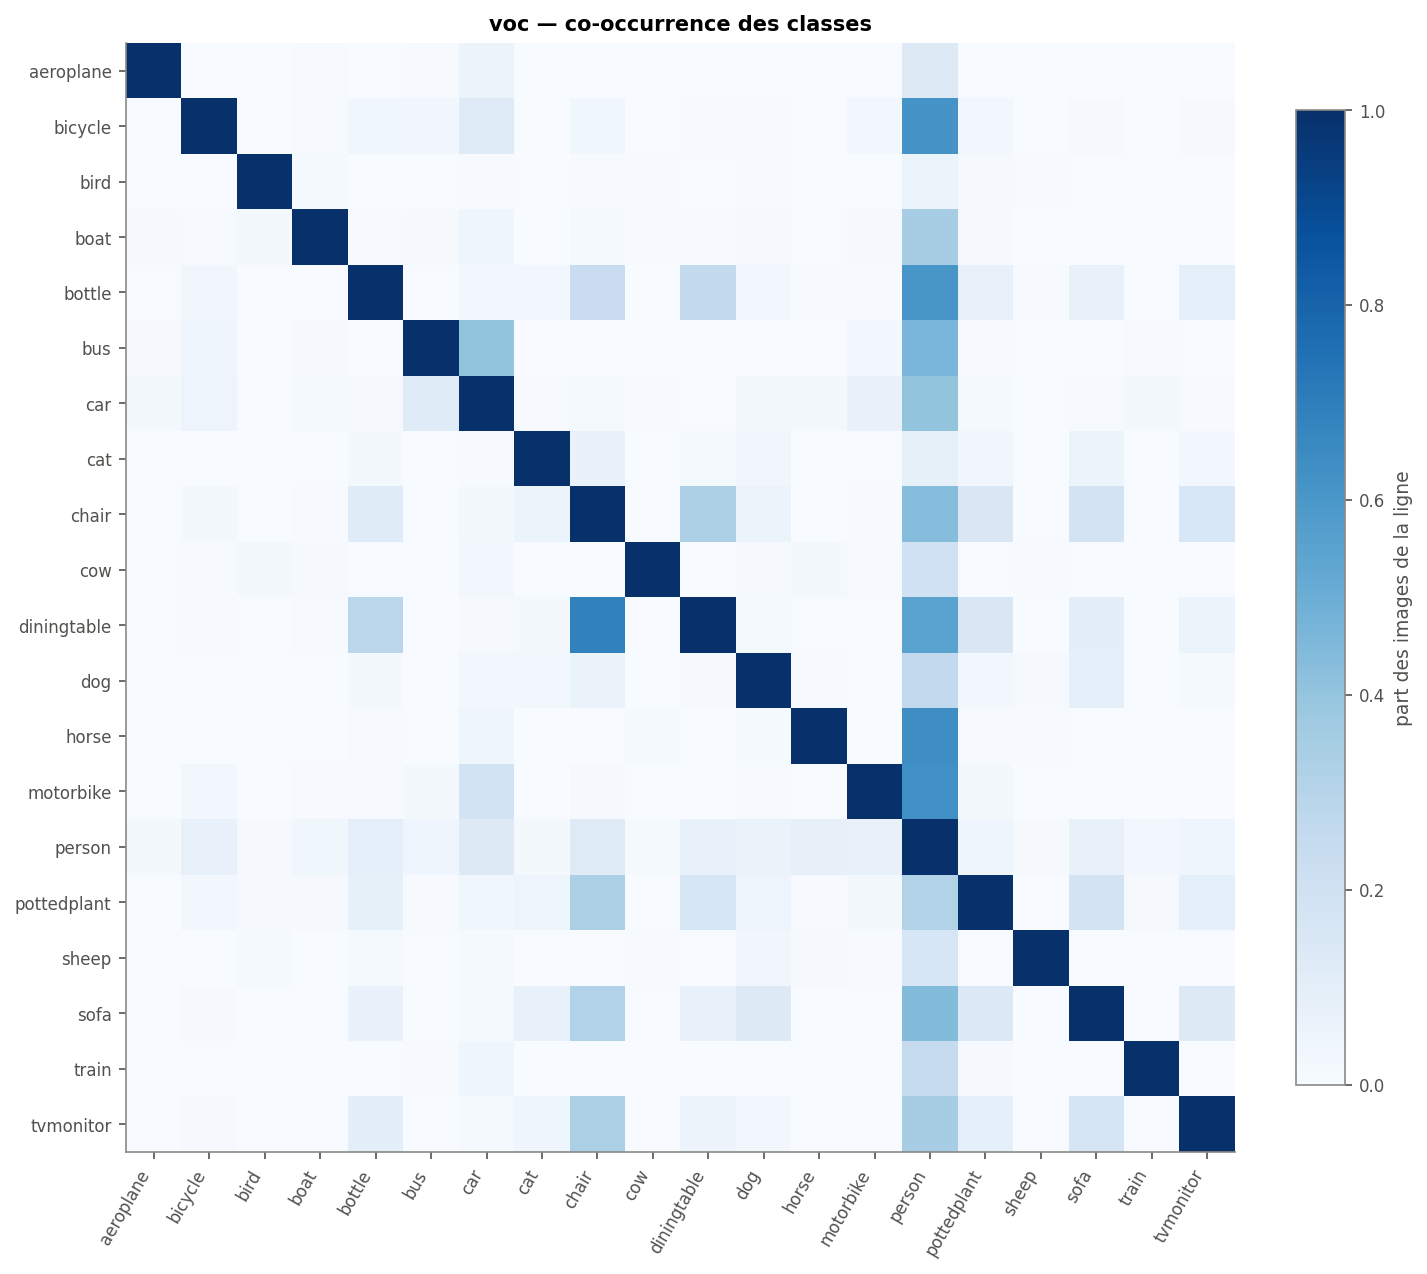

In [5]:
table(DS.md_synthese)
chk = DS.check_official(STATS)
for sp, i, o, (a, b), ok in chk:
    print(f"{sp} : {i} images, {o} objets ; officiel {a or '—'} / {b or '—'} : "
          f"{'ok' if ok else 'écart (voir les notes de la fiche)'}")
table(DS.md_classes)
show("classes")
show("cooccurrence")

## Géométrie des boîtes (T16.6)

Tailles en pixels d'origine et d'entrée (letterbox et stretch à `SIZE`), catégories
COCO avant et après redimensionnement, part des objets plus petits qu'une cellule de
chaque tête, centres des boîtes.

| repère | petits | moyens | grands | côté médian (px) | plus petits qu'une cellule | hauteur < 8 px |
|---|---|---|---|---|---|---|
| image d'origine | 5,2 % | 30,2 % | 64,7 % | 139 | — | — |
| letterbox 416×416 | 8,4 % | 33,7 % | 58,0 % | 116 | 13x13 4,0 % · 26x26 0,3 % | 0,0 % |
| stretch 416×416 | 5,3 % | 30,4 % | 64,2 % | 137 | 13x13 2,0 % · 26x26 0,1 % | 0,0 % |

52 090 objets non-difficult ; pas des têtes : 13x13 → 32 px, 26x26 → 16 px.

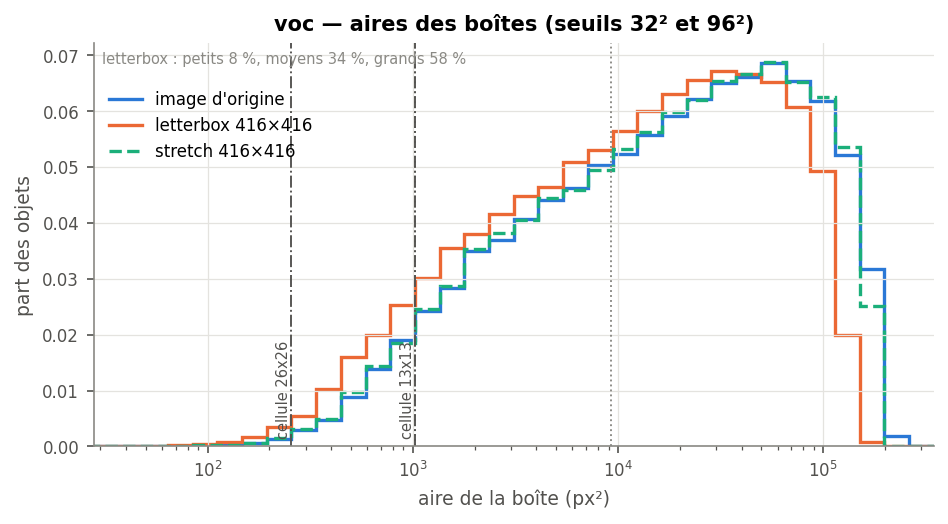

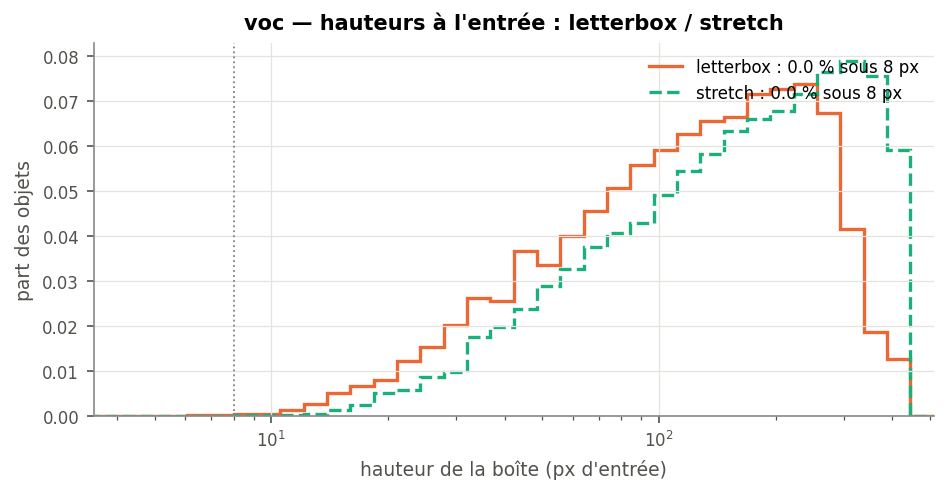

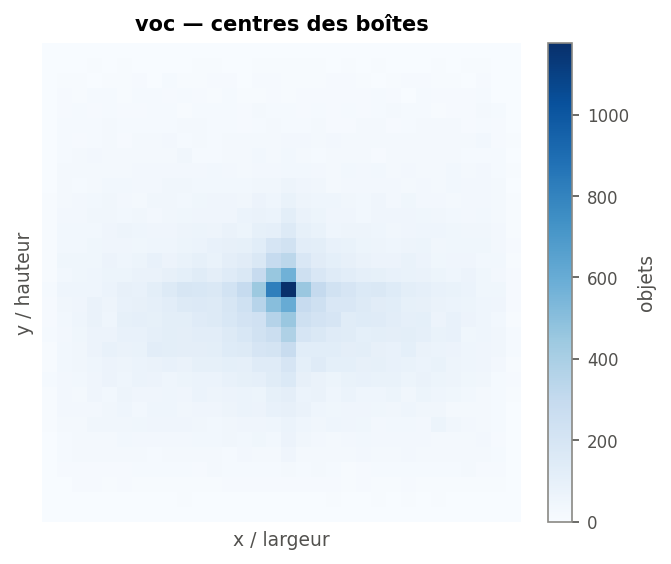

In [6]:
table(DS.md_geometrie)
show("tailles")
show("letterbox_stretch")
show("centres")

## Densité et collisions (T16.7)

Objets par image face aux 256 emplacements de `yolo_post` ; cibles perdues quand deux
objets tombent sur la même cellule et la même ancre (`build_targets`, ancres de `NET`).

| partie | objets/image moy. | méd. | max | > 256 / > 1 024 | cibles perdues | par tête (perdues / objets) | images touchées |
|---|---|---|---|---|---|---|---|
| 2007:trainval | 3,1 | 2 | 42 | 0 / 0 | 78 / 12 608 (0,62 %) | 13x13 : 58 / 9 128 · 26x26 : 20 / 3 480 | 78 |
| 2012:trainval | 2,7 | 2 | 56 | 0 / 0 | 200 / 27 450 (0,73 %) | 13x13 : 136 / 20 427 · 26x26 : 64 / 7 023 | 186 |
| 2007:test | 3,0 | 2 | 41 | 0 / 0 | 79 / 12 032 (0,66 %) | 13x13 : 60 / 8 857 · 26x26 : 19 / 3 175 | 75 |
| groupe train | 2,9 | 2 | 56 | 0 / 0 | 278 / 40 058 (0,69 %) | 13x13 : 194 / 29 555 · 26x26 : 84 / 10 503 | 264 |
| ensemble | 2,9 | 2 | 56 | 0 / 0 | 357 / 52 090 (0,69 %) | 13x13 : 254 / 38 412 · 26x26 : 103 / 13 678 | 339 |

Ancres de `tiny-yolov3-voc` ; objets non-difficult, comme à l'entraînement.

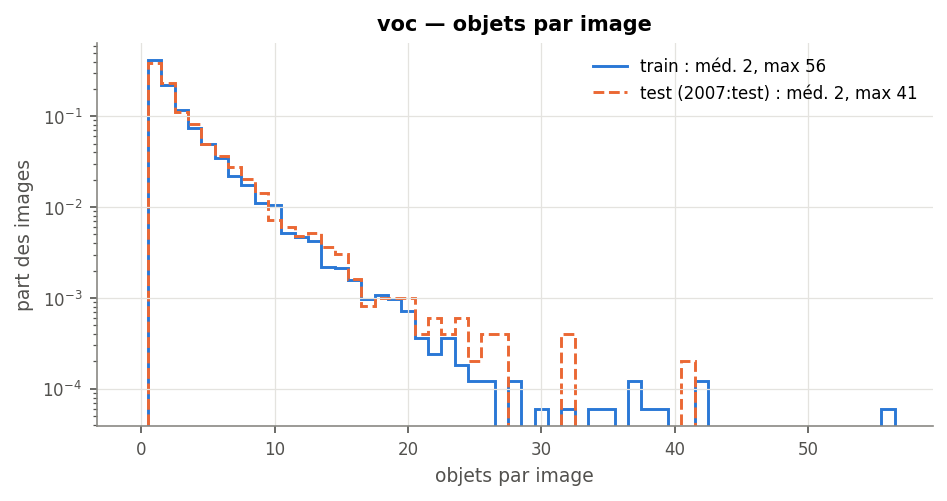

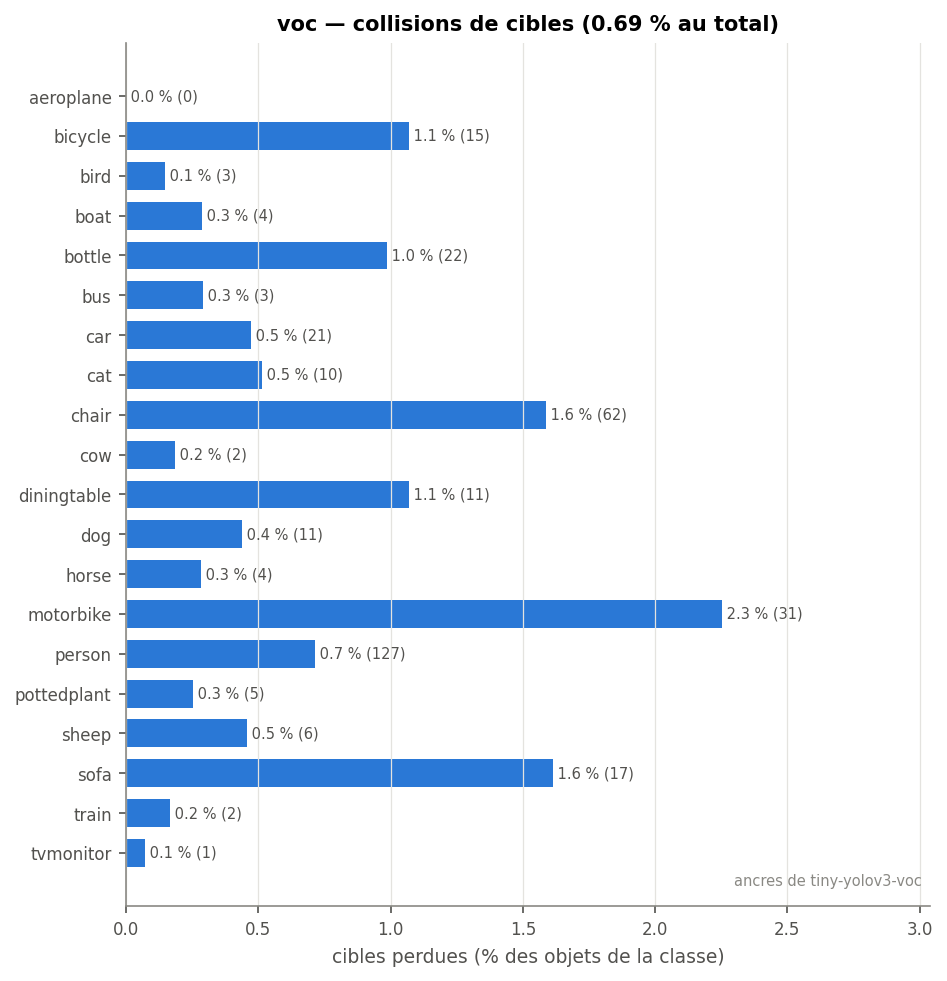

In [7]:
table(DS.md_densite)
show("densite")
show("collisions")

## Images (T16.8)

Résolutions sur le split entier (annotations) ; canaux, intensités et luminance sur
`SAMPLE` images par partie, face à VOC2007 test (échelles INT8 de M4).

| partie | résolutions (3 premières) | distinctes | pixels sur | canaux | moyenne par canal | écart type par canal | luminance moy. | niveaux 8 bits → INT8 |
|---|---|---|---|---|---|---|---|---|
| 2007:trainval | 500×375 (2 142), 500×333 (685), 375×500 (393) | 486 | 200 images | 3 | 115,6 / 110,5 / 102,4 | 70,7 / 69,7 / 72,8 | 111,5 | 256 → 128 |
| 2012:trainval | 500×375 (4 815), 500×333 (1 502), 375×500 (1 006) | 772 | 200 images | 3 | 116,2 / 112,2 / 103,7 | 66,0 / 66,7 / 71,5 | 112,6 | 256 → 128 |
| 2007:test | 500×375 (2 090), 500×333 (747), 375×500 (377) | 514 | 200 images | 3 | 112,1 / 107,1 / 98,5 | 71,0 / 70,6 / 73,2 | 107,7 | 256 → 128 |
| groupe train | 500×375 (6 957), 500×333 (2 187), 375×500 (1 399) | 925 | 200 images | 3 | 110,3 / 105,2 / 96,1 | 70,1 / 69,2 / 71,0 | 105,7 | 256 → 128 |
| ensemble | 500×375 (9 047), 500×333 (2 934), 375×500 (1 776) | 1 090 | 200 images | 3 | 117,8 / 111,0 / 101,5 | 68,0 / 67,5 / 71,2 | 111,9 | 256 → 128 |

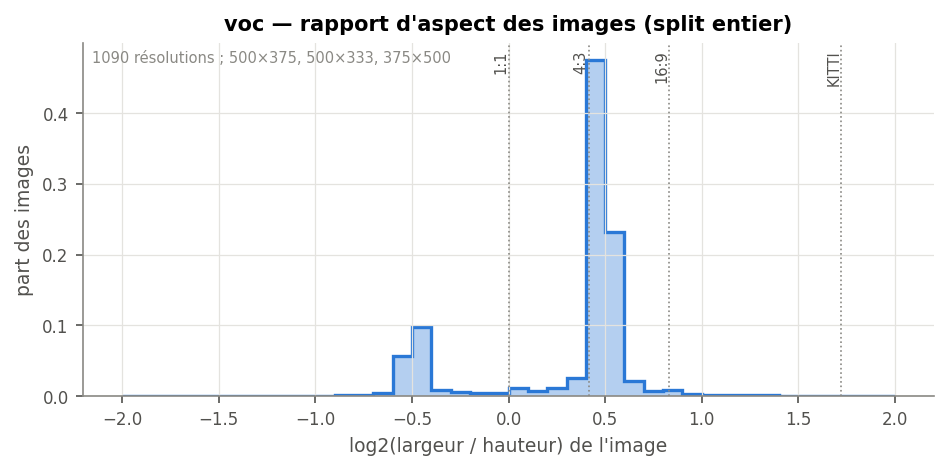

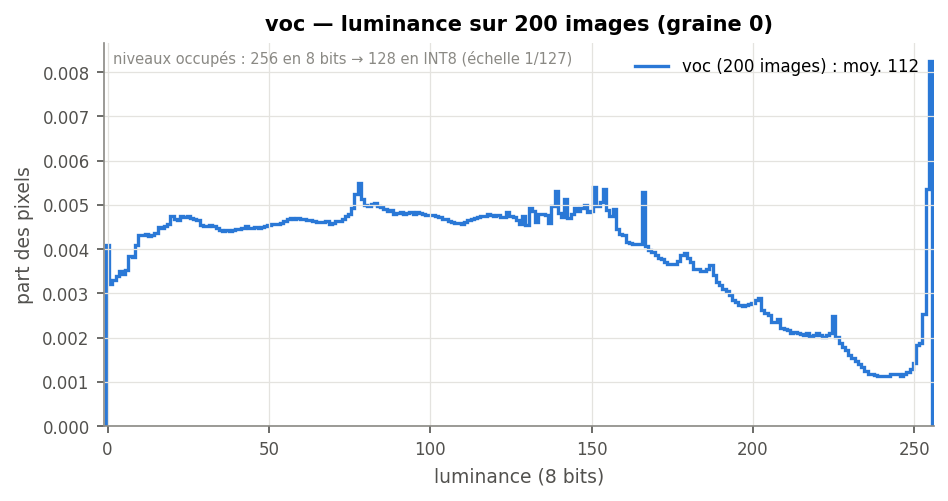

In [8]:
table(DS.md_images)
show("resolutions")
show("intensites")

## Ancres (T16.9)

Boîtes du groupe train en pixels d'entrée letterbox, ancres de la cfg, de VOC, de
COCO et du k-means (`tools/kmeans_anchors.py`, mêmes `--size` et `--seed`).

| ancres | w,h (px à 416×416) | IoU moyenne |
|---|---|---|
| VOC (tiny-yolov2-voc) | `35,38  109,141  212,364  301,164  532,337` | 0,5591 |
| VOC (tiny-yolov3-voc) | `10,14  23,27  37,58  81,82  135,169  344,319` | 0,6029 |
| COCO (tiny-yolov3-coco) | `10,14  23,27  37,58  81,82  135,169  344,319` | 0,6029 |
| cfg du jeu (tiny-yolov3-voc) | `10,14  23,27  37,58  81,82  135,169  344,319` | 0,6029 |
| k-means k = 5 (graine 0) | `38,49  90,112  141,225  264,135  312,278` | 0,6113 |
| k-means k = 6 (graine 0) | `35,47  84,95  109,192  252,129  193,263  341,269` | 0,6307 |

40 058 boîtes non-difficult du groupe train, letterbox 416×416.

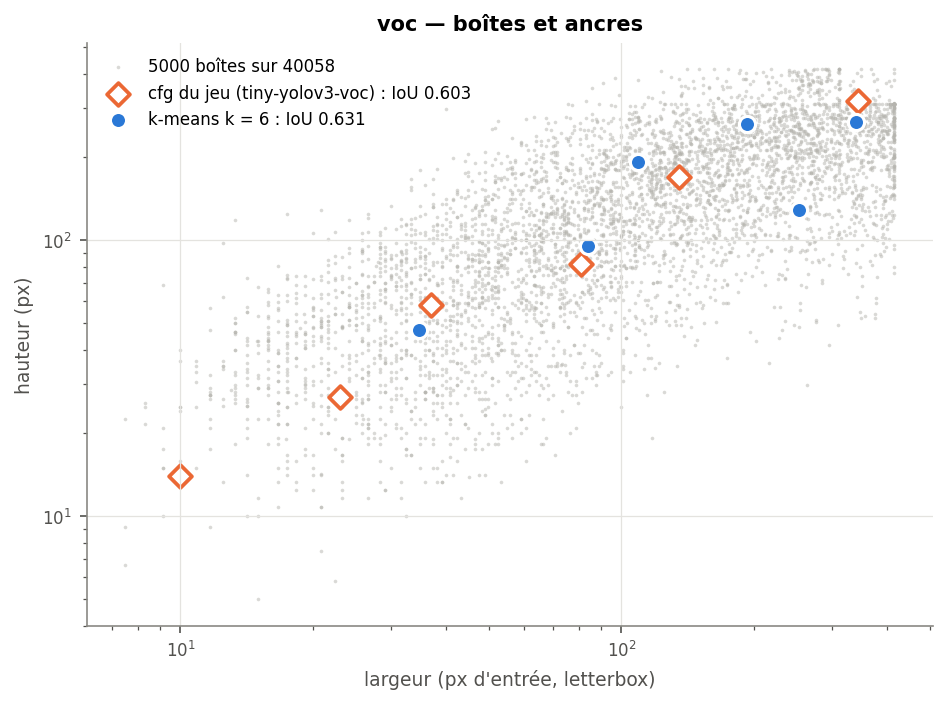

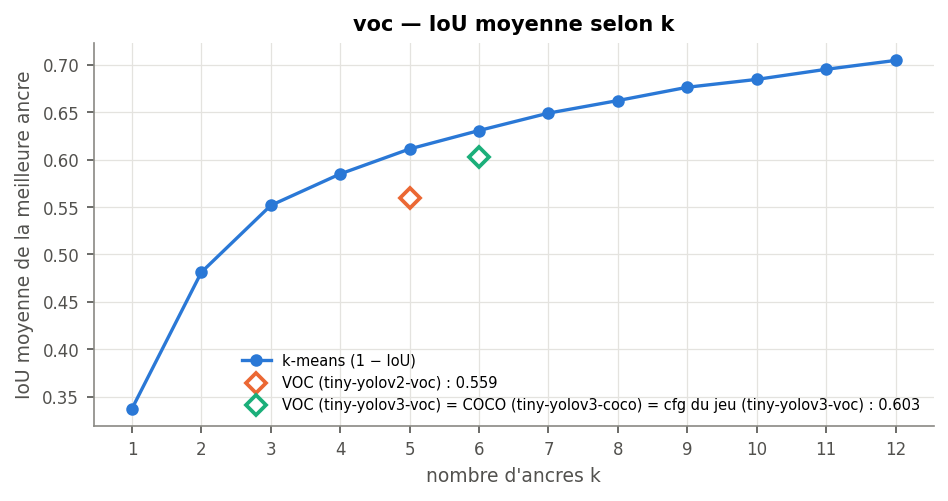

In [9]:
table(DS.md_ancres)
show("ancres")
show("ancres_k")

## Qualité des annotations (T16.10)

Boîtes retirées ou rognées par le chargeur, dégénérées, doublons, régions retirées ;
l'analyse signale, elle ne corrige pas (une correction passe par M11).

| partie | retirées (make_sample) | rognées | côté < 2 px (orig. / entrée) | doublons (IoU > 0,95) | régions retirées par le chargeur |
|---|---|---|---|---|---|
| 2007:trainval | — | 0 | 0 / 0 | 2 | — |
| 2012:trainval | — | 0 | 0 / 0 | 1 | — |
| 2007:test | — | 0 | 0 / 0 | 0 | — |
| groupe train | — | 0 | 0 / 0 | 3 | — |
| ensemble | — | 0 | 0 / 0 | 3 | — |

003261 : score 2 (retirées 0, rognées 0, dégénérées 0, doublons 1)
004437 : score 2 (retirées 0, rognées 0, dégénérées 0, doublons 1)
2008_001591 : score 2 (retirées 0, rognées 0, dégénérées 0, doublons 1)


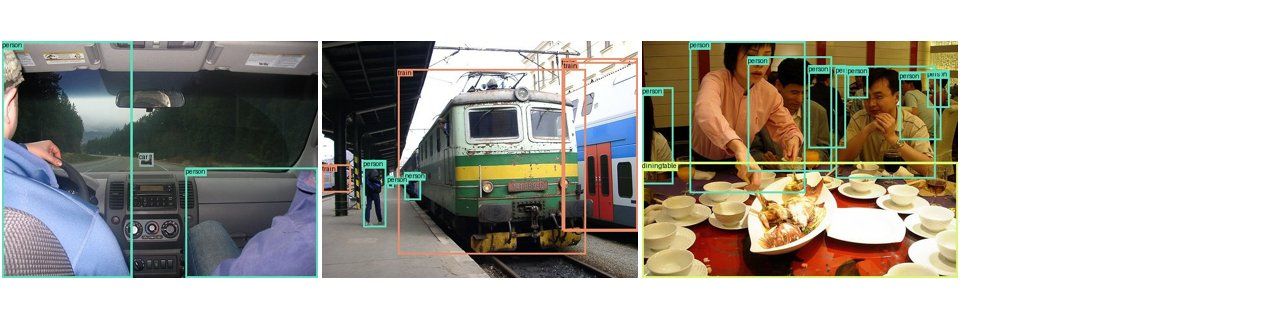

In [10]:
table(DS.md_qualite)
sus = DS.whole(STATS).get("qualite", {}).get("suspects", [])
for d in sus:
    print(f"{d['id']} : score {d['score']} (retirées {d['retirées']}, rognées "
          f"{d['rognées']}, dégénérées {d['dégénérées']}, doublons {d['doublons']})")
sheet = STATS.get("galerie", {}).get("planches", {}).get("suspectes")
if sheet:
    display(Img(filename=str(Path(OUT, sheet))))

## Écart entre splits et couverture hors domaine (T16.11)

Distance en variation totale entre train et test, par grandeur ; part des objets qui
ont une classe VOC ou COCO (ce qu'évaluent les notebooks hors domaine de T14.5).

| grandeur (train ↔ test) | variation totale |
|---|---|
| classes | 0,044 |
| area_in | 0,040 |
| w_in | 0,028 |
| h_in | 0,039 |
| aspect | 0,026 |
| per_image | 0,039 |

| split | classes du modèle | objets couverts | part | évalués (non-difficult) |
|---|---|---|---|---|
| 2007:trainval | VOC | 15 662 | 100,0 % | 12 608 |
| 2007:trainval | COCO | 15 662 | 100,0 % | 12 608 |
| 2012:trainval | VOC | 31 561 | 100,0 % | 27 450 |
| 2012:trainval | COCO | 31 561 | 100,0 % | 27 450 |
| 2007:test | VOC | 14 976 | 100,0 % | 12 032 |
| 2007:test | COCO | 14 976 | 100,0 % | 12 032 |

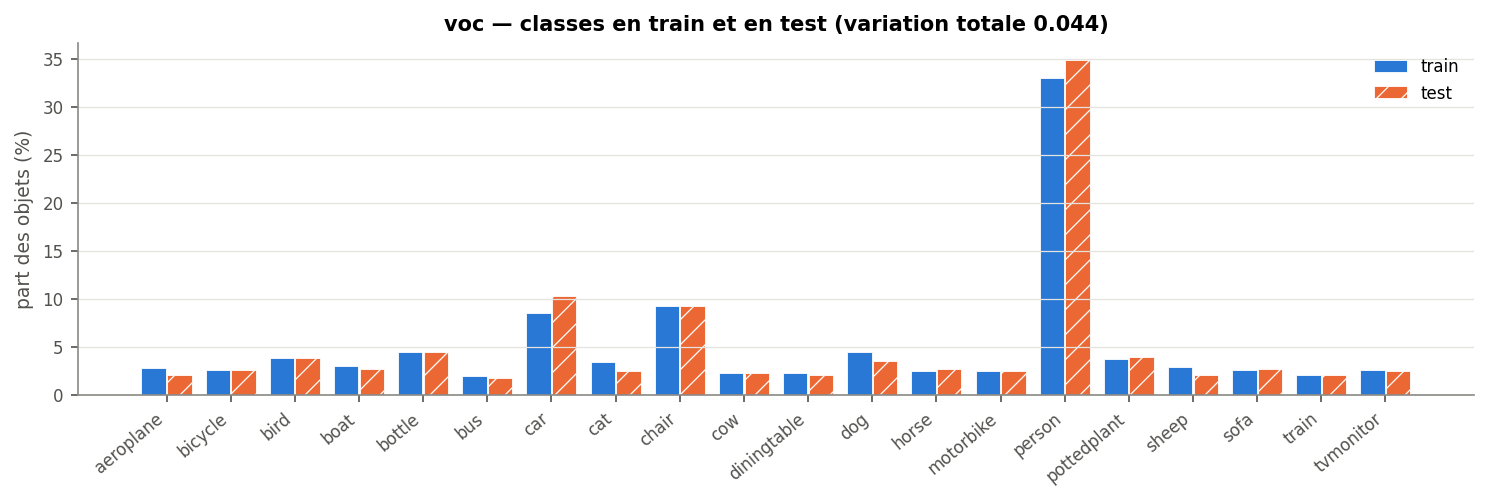

In [11]:
table(DS.md_ecart)
show("ecart")

## Question propre au jeu

Les classes à faible AP (bottle, pottedplant) sont-elles rares ou petites ? (renvoi : T13.7, T13.13)

In [12]:
ap = DS.voc_ap()
if ap:
    print(f"AP flottante par classe : {ap['source']} (Tiny-YOLOv2 VOC, VOC2007 test)")
display(Markdown(DS.md_par_classe(STATS, ap.get("ap") if ap else None)))

AP flottante par classe : results/map_stades.md (Tiny-YOLOv2 VOC, VOC2007 test)


| classe | objets (test, non-difficult) | part | côté médian (px) | petits | cibles perdues | AP |
|---|---|---|---|---|---|---|
| aeroplane | 285 | 2,4 % | 131 | 15 % | 0,00 % | 61,4 |
| bicycle | 337 | 2,8 % | 142 | 0 % | 1,19 % | 71,6 |
| bird | 459 | 3,8 % | 109 | 7 % | 0,00 % | 48,5 |
| boat | 263 | 2,2 % | 105 | 12 % | 0,00 % | 41,5 |
| bottle | 469 | 3,9 % | 55 | 15 % | 0,43 % | 21,6 |
| bus | 213 | 1,8 % | 173 | 1 % | 0,00 % | 67,8 |
| car | 1 201 | 10,0 % | 93 | 11 % | 0,33 % | 67,0 |
| cat | 358 | 3,0 % | 222 | 0 % | 0,28 % | 70,4 |
| chair | 756 | 6,3 % | 91 | 2 % | 1,46 % | 35,3 |
| cow | 244 | 2,0 % | 90 | 7 % | 0,41 % | 54,6 |
| diningtable | 206 | 1,7 % | 192 | 0 % | 0,97 % | 57,5 |
| dog | 489 | 4,1 % | 189 | 0 % | 0,82 % | 62,3 |
| horse | 348 | 2,9 % | 186 | 1 % | 0,29 % | 70,9 |
| motorbike | 325 | 2,7 % | 150 | 2 % | 3,08 % | 70,5 |
| person | 4 528 | 37,6 % | 107 | 10 % | 0,71 % | 60,6 |
| pottedplant | 480 | 4,0 % | 80 | 9 % | 0,62 % | 27,5 |
| sheep | 242 | 2,0 % | 89 | 12 % | 0,00 % | 56,5 |
| sofa | 239 | 2,0 % | 190 | 0 % | 1,26 % | 52,1 |
| train | 282 | 2,3 % | 193 | 0 % | 0,35 % | 69,7 |
| tvmonitor | 308 | 2,6 % | 93 | 5 % | 0,00 % | 58,6 |

## Résumé

In [13]:
table(DS.md_synthese)
print(f"sorties : {OUT}/ (stats.json, stats.md, figures/, galerie/) ; "
      f"révision {TRACE['rev']}")
print("commandes équivalentes :")
for c in C.HISTORY:
    print("  " + c)

| partie | images | objets | difficult | images vides | objets/image (méd. / max) | petits < 32² à 416×416 | plus petits qu'une cellule | cibles perdues | images > 256 / > 1 024 |
|---|---|---|---|---|---|---|---|---|---|
| 2007:trainval | 5 011 | 15 662 | 3 054 | 0 | 2 / 42 | 7,7 % | 13x13 3,2 % · 26x26 0,1 % | 0,62 % | 0 / 0 |
| 2012:trainval | 11 540 | 31 561 | 4 111 | 0 | 2 / 56 | 9,1 % | 13x13 4,7 % · 26x26 0,4 % | 0,73 % | 0 / 0 |
| 2007:test | 4 952 | 14 976 | 2 944 | 0 | 2 / 41 | 7,3 % | 13x13 3,5 % · 26x26 0,1 % | 0,66 % | 0 / 0 |
| groupe train | 16 551 | 47 223 | 7 165 | 0 | 2 / 56 | 8,7 % | 13x13 4,2 % · 26x26 0,3 % | 0,69 % | 0 / 0 |
| ensemble | 21 503 | 62 199 | 10 109 | 0 | 2 / 56 | 8,4 % | 13x13 4,0 % · 26x26 0,3 % | 0,69 % | 0 / 0 |

sorties : build/notebooks/voc/stats/ (stats.json, stats.md, figures/, galerie/) ; révision 214f269
commandes équivalentes :
  python tools/data_stats.py --dataset voc --size 416 --resize letterbox --net tiny-yolov3-voc --sample 200 --gallery 8 --seed 0 --figures --out build/notebooks/voc/stats
